# Quantum data example in Kappen (2018)
This notebook reproduces the example in Section 4 of [Kappen](https://arxiv.org/abs/1803.11278)

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))  # go up two levels (from numerics to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# # Ensure packages are installed
# for pkg in [
#     "PauliPropagation", "Plots", "LinearAlgebra", "ProgressMeter", "Distributions",
#     "Random", "Optimisers", "ReverseDiff", "MAT", "BenchmarkTools", "IterTools", "StatsBase", "LaTeXStrings", "Measures", "CSV", "DataFrames", "JSON3", "Dates"
# ]
#     Pkg.add(pkg)
# end

In [3]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures, CSV, DataFrames, JSON3, Dates

In [4]:
# define number of sites == number of qubits (each site is a 2-level system)
n = 6 ## change this to 10 to reproduce the paper results

6

## Target state

The quantum state we set up to learn using a QBM is a thermal state (for three different temperatures) from the Hamiltonian of the 1D Heisenberg model with nearest-neighbors interactions, isotropic couplings and zero single-site fields. We report here the full Eq. (13) of the [paper](https://arxiv.org/abs/1803.11278):
\begin{equation}
H = \sum_{i=1}^{n} \sum_{k = x, y, z} w_i^{k} \sigma_i^{k}
    + \sum_{i=1}^{n} \sum_{j > i}^{n} \sum_{k = x, y, z} w_{ij}^{k} \sigma_i^{k} \sigma_j^{k},
\end{equation}
where $\sigma_j^{k}$ are Pauli operators on site $j$ and $n$ is the total number of sites.

The target state is generated with the Hamiltonian where
$$
w_{ij}^{x,y,z} = 1 \text{ for nearest neighbors,} \quad 
w_{ij}^{x,y,z} = 0 \text{ otherwise, and } w_i^{k} = 0.
$$


### Hamiltonian 
For this example, we work under the (simplifying) assumption that each spin direction will have a separate parameter, but that the interaction in a fixed spin direction is isotropic along the spin chain of 
sites (we also include periodic boundary conditions). This amounts to the Hamiltonian of the `XYZ` Heisenberg model, but when the `x`, `y`, and `z` couplings are the same, then it is the `XXX` Heisenberg model:

In [5]:
# Fix the parameters of the hamiltonian:
# - 3 parameters for the nearest-neighbors terms
target_interactions = (1.0, 1.0, 1.0)
@printf("Spin interaction used to create target state: %s\n", target_interactions)

Spin interaction used to create target state: (1.0, 1.0, 1.0)


In [6]:
target_interactions = 4 .* target_interactions
params_target = parameters(:heisenberg, n; coupling_vals=Dict(:XX => target_interactions[1], :YY => target_interactions[2], :ZZ => target_interactions[3]))

target_xxx = makehamiltonian(params_target; connectivity=:nearest, periodic=true)

18-element Vector{PauliString}:
 PauliString(nqubits: 6, 1.0 * XXIIII)
 PauliString(nqubits: 6, 1.0 * YYIIII)
 PauliString(nqubits: 6, 1.0 * ZZIIII)
 PauliString(nqubits: 6, 1.0 * IXXIII)
 PauliString(nqubits: 6, 1.0 * IYYIII)
 PauliString(nqubits: 6, 1.0 * IZZIII)
 PauliString(nqubits: 6, 1.0 * IIXXII)
 PauliString(nqubits: 6, 1.0 * IIYYII)
 PauliString(nqubits: 6, 1.0 * IIZZII)
 PauliString(nqubits: 6, 1.0 * IIIXXI)
 PauliString(nqubits: 6, 1.0 * IIIYYI)
 PauliString(nqubits: 6, 1.0 * IIIZZI)
 PauliString(nqubits: 6, 1.0 * IIIIXX)
 PauliString(nqubits: 6, 1.0 * IIIIYY)
 PauliString(nqubits: 6, 1.0 * IIIIZZ)
 PauliString(nqubits: 6, 1.0 * XIIIIX)
 PauliString(nqubits: 6, 1.0 * YIIIIY)
 PauliString(nqubits: 6, 1.0 * ZIIIIZ)

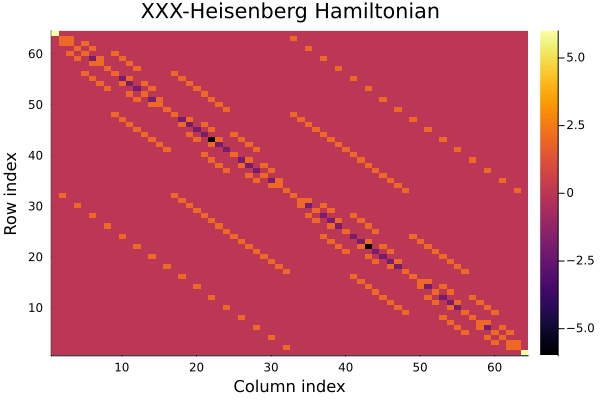

In [7]:
target_xxx_matrix = paulistringtomatrix(target_xxx)

heatmap(reverse(real(target_xxx_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="XXX-Heisenberg Hamiltonian"
        )

### Density matrix

The paper generates a density matrix from the `XXX ` Hamiltonian at 3 different temperatures $T = 1/\beta$
, with $\beta =1,2,∞$

In [8]:
num_layers = 100
max_weight = n
min_abs_coeff = 1e-20;

In [9]:
target_beta01 = .1

target_xxx_beta01 = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * target_beta01
target_xxx_matrix_beta01 = paulistringtomatrix(target_xxx_beta01)
targert_circuit_beta01, θ_beta01 = paulistringtocircuit(target_xxx_beta01)

target_eta_beta01 = makethermalstate(n, targert_circuit_beta01, θ_beta01, num_layers;
                                  max_weight=max_weight, min_abs_coeff=min_abs_coeff)

target_eta_beta01_matrix = paulistringtomatrix(target_eta_beta01);

In [10]:
target_beta1 = 1

target_xxx_beta1 = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * target_beta1
target_xxx_matrix_beta1 = paulistringtomatrix(target_xxx_beta1)
targert_circuit_beta1, θ_beta1 = paulistringtocircuit(target_xxx_beta1)

target_eta_beta1 = makethermalstate(n, targert_circuit_beta1, θ_beta1, num_layers;
                                  max_weight=max_weight, min_abs_coeff=min_abs_coeff)

target_eta_beta1_matrix = paulistringtomatrix(target_eta_beta1);

In [11]:
target_beta2 = 2

target_xxx_beta2 = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * target_beta2
target_xxx_matrix_beta2 = paulistringtomatrix(target_xxx_beta2)
targert_circuit_beta2, θ_beta2 = paulistringtocircuit(target_xxx_beta2)

target_eta_beta2 = makethermalstate(n, targert_circuit_beta2, θ_beta2, num_layers;
                                  max_weight=max_weight, min_abs_coeff=min_abs_coeff)

target_eta_beta2_matrix = paulistringtomatrix(target_eta_beta2);

In [12]:
target_beta∞ = 60

target_xxx_beta∞ = makehamiltonian(params_target; connectivity=:nearest, periodic=true) * target_beta∞
target_xxx_matrix_beta∞ = paulistringtomatrix(target_xxx_beta∞)
targert_circuit_beta∞, θ_beta∞ = paulistringtocircuit(target_xxx_beta∞)

target_eta_beta∞ = makethermalstate(n, targert_circuit_beta∞, θ_beta∞, num_layers;
                                  max_weight=max_weight, min_abs_coeff=min_abs_coeff)

target_eta_beta∞_matrix = paulistringtomatrix(target_eta_beta∞);

## Quantum Boltzmann Machine model

Following the paper we now define the QBM based on the same `XYZ` Heisenberg Hamiltonian used to define the target state. We let the 3 parameters for each spin direction to have arbitrary values.

In [13]:
# parameters to learn. Set initial values at random
rng = MersenneTwister()  
interactions = Tuple(randn(rng, 3))        
fields       = Tuple(randn(rng, 3))
@printf("Spin interaction: %s\n", interactions)
@printf("Field value: %s\n", fields)

Spin interaction: (-1.3607559782914551, 0.9238434799592412, 0.7938200372795047)
Field value: (0.7425703425193445, 0.5429880981389806, -0.7448388693621841)


In [14]:
params = parameters(:heisenberg_fields, n; field_vals=Dict(:X => fields[1], :Y => fields[2], :Z => fields[3]), coupling_vals=Dict(:XX => interactions[1], :YY => interactions[2], :ZZ => interactions[3]))

beta_qbm = 1
qbm_xyz = makehamiltonian(params; connectivity=:nearest, periodic=true) * beta_qbm

36-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, 0.37129 * XIIIII)
 PauliString(nqubits: 6, 0.27149 * YIIIII)
 PauliString(nqubits: 6, -0.37242 * ZIIIII)
 PauliString(nqubits: 6, 0.37129 * IXIIII)
 PauliString(nqubits: 6, 0.27149 * IYIIII)
 PauliString(nqubits: 6, -0.37242 * IZIIII)
 PauliString(nqubits: 6, 0.37129 * IIXIII)
 PauliString(nqubits: 6, 0.27149 * IIYIII)
 PauliString(nqubits: 6, -0.37242 * IIZIII)
 PauliString(nqubits: 6, 0.37129 * IIIXII)
 ⋮
 PauliString(nqubits: 6, -0.34019 * IIIXXI)
 PauliString(nqubits: 6, 0.23096 * IIIYYI)
 PauliString(nqubits: 6, 0.19846 * IIIZZI)
 PauliString(nqubits: 6, -0.34019 * IIIIXX)
 PauliString(nqubits: 6, 0.23096 * IIIIYY)
 PauliString(nqubits: 6, 0.19846 * IIIIZZ)
 PauliString(nqubits: 6, -0.34019 * XIIIIX)
 PauliString(nqubits: 6, 0.23096 * YIIIIY)
 PauliString(nqubits: 6, 0.19846 * ZIIIIZ)

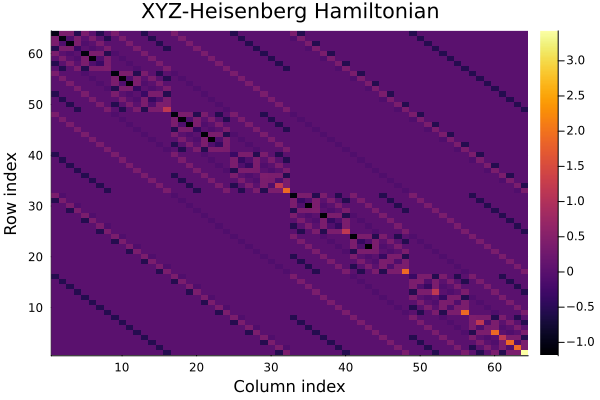

In [15]:
qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)

heatmap(reverse(real(qbm_xyz_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="XYZ-Heisenberg Hamiltonian"
        )

### Gibbs state
The corresponding Gibbs state for this initial Hamiltonian is
$$\rho_\theta = \frac{e^{H_\theta}}{Z}$$

In [16]:
trial_circuit, trial_θ = paulistringtocircuit(qbm_xyz)
num_layers = 100
max_weight = n
min_abs_coeff = 1e-20

rho_qbm = makethermalstate(n, trial_circuit, trial_θ, num_layers;
                                  max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)

rho_qbm_matrix = paulistringtomatrix(rho_qbm);

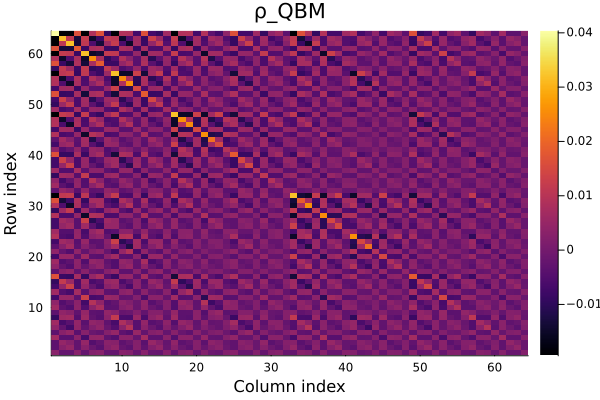

In [17]:
heatmap(reverse(real(rho_qbm_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="ρ_QBM"
        )

## Training of the QBM


In [18]:
target_probs_beta01 = computesymmetriceigenvalues(target_eta_beta01_matrix)
target_probs_beta01 = clamp.(target_probs_beta01, 1e-300, Inf);

target_probs_beta1 = computesymmetriceigenvalues(target_eta_beta1_matrix)
target_probs_beta1 = clamp.(target_probs_beta1, 1e-300, Inf);

target_probs_beta2 = computesymmetriceigenvalues(target_eta_beta2_matrix)
target_probs_beta2 = clamp.(target_probs_beta2, 1e-300, Inf);

target_probs_beta∞ = computesymmetriceigenvalues(target_eta_beta∞_matrix)
target_probs_beta∞ = clamp.(target_probs_beta∞ , 1e-300, Inf);

In [ ]:
beta = 1

params = parameters(:heisenberg_fields, n; field_vals=Dict(:X => fields[1], :Y => fields[2], :Z => fields[3]), coupling_vals=Dict(:XX => interactions[1], :YY => interactions[2], :ZZ => interactions[3]))

# learning rate
gamma = 0.2
# number of epochs
epochs = 2000

# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-6
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

for epoch in 1:epochs
    qbm_xyz = makehamiltonian(params) * beta
    qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)
    push!(qre_hist, computequantumrelativeentropy(target_eta_beta1_matrix, target_probs_beta1,     qbm_xyz_matrix))

    # create qbm state
    circuit, theta = paulistringtocircuit(qbm_xyz)
    num_layers = 100
    max_weight = n
    min_abs_coeff = 1e-10
    rho = makethermalstate(n, circuit, theta, num_layers;
                                    max_weight=max_weight, min_abs_coeff=min_abs_coeff)
    rho_matrix = paulistringtomatrix(rho)

    # Compute and record gradient
    grads = computegradients(params, target_eta_beta1, rho)
    flat_grads = vcat(
        reduce(vcat, grads.wi_xyz)...,
        reduce(vcat, [vec(g) for g in grads.wij_xyz])...
    )
    push!(grad_hist, abs.(flat_grads))

    # Update parameters
    updateparameters!(params, grads, gamma)

    # Print diagnostics
    if epoch % 100 == 0
        @printf("\nEpoch %d\n", epoch)
        @printf("  Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("  Max abs gradient:         %.6f\n", maximum(grad_hist[end]))
    end

    # Stop if converged
    if maximum(grad_hist[end]) < epsilon
        println("Converged: max gradient < epsilon")
        break
    end
end


Epoch 100
  Quantum relative entropy: 0.565217
  Max abs gradient:         0.058037

Epoch 200
  Quantum relative entropy: 0.553485
  Max abs gradient:         0.021683

Epoch 300
  Quantum relative entropy: 0.551560
  Max abs gradient:         0.009900

Epoch 400
  Quantum relative entropy: 0.551140
  Max abs gradient:         0.004835

Epoch 500
  Quantum relative entropy: 0.551040
  Max abs gradient:         0.002432

Epoch 600
  Quantum relative entropy: 0.551015
  Max abs gradient:         0.001241

Epoch 700
  Quantum relative entropy: 0.551009


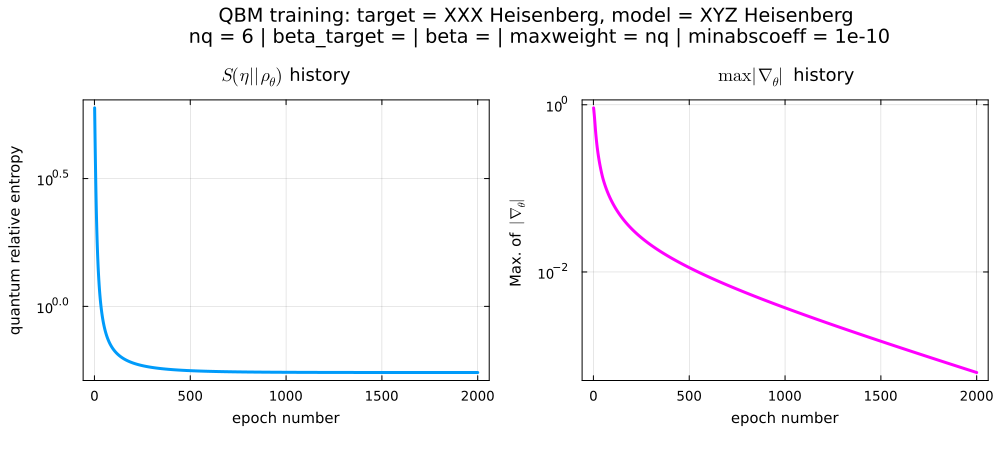

In [20]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = XXX Heisenberg, model = XYZ Heisenberg\n nq = 6 | beta_target = | beta = | maxweight = nq | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)

In [44]:
@printf("Original target parameters:\n field = %s\ninteraction = %s\n", params_target.wi_xyz, params_target.wij_xyz)

Original target parameters:
 field = ([0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
interaction = ([4.0 4.0 4.0 4.0 4.0 4.0; 4.0 4.0 4.0 4.0 4.0 4.0; 4.0 4.0 4.0 4.0 4.0 4.0; 4.0 4.0 4.0 4.0 4.0 4.0; 4.0 4.0 4.0 4.0 4.0 4.0; 4.0 4.0 4.0 4.0 4.0 4.0], [0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0], [0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0], [0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0], [4.0 4.0 4.0 4.0 4.0 4.0; 4.0 4.0 4.0 4.0 4.0 4.0; 4.0 4.0 4.0 4.0 4.0 4.0; 4.0 4.0 4.0 4.0 4.0 4.0; 4.0 4.0 4.0 4.0 4.0 4.0; 4.0 4.0 4.0 4.0 4.0 4.0], [0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0

In [45]:
@printf("Trained QBM parameters:\n field = %s\ninteraction = %s\n", params.wi_xyz, params.wij_xyz)

Trained QBM parameters:
 field = ([3.1802325601004654e-8, 7.745371763194957e-8, 1.2486202861214787e-7, 1.2752715015331187e-7, 7.855367561332195e-8, 3.2621479920787754e-8], [-4.0221851489714424e-8, -1.3974476467006262e-7, -2.4435671865747185e-7, -2.453928489846965e-7, -1.3990052243795568e-7, -4.274280590969048e-8], [-2.8547317086785586e-8, -5.996284773199327e-8, -8.863310945352564e-8, -9.39869969714716e-8, -6.241426817812777e-8, -3.150207743222921e-8])
interaction = ([0.7671269958455564 3.1348945144876446 0.7671269958455564 0.7671269958455564 0.7671269958455564 0.7671269958455564; 3.1348945144876446 0.7671269958455564 4.671695305153165 0.7671269958455564 0.7671269958455564 0.7671269958455564; 0.7671269958455564 4.671695305153165 0.7671269958455564 5.100770842931324 0.7671269958455564 0.7671269958455564; 0.7671269958455564 0.7671269958455564 5.100770842931324 0.7671269958455564 4.711604370476366 0.7671269958455564; 0.7671269958455564 0.7671269958455564 0.7671269958455564 4.71160437047636

In [36]:
params = HamiltonianParams(n; wi_xyz=b, wij_xyz=j)
beta = 1
# learning rate
gamma = 0.2
# number of epochs
epochs = 1000

# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-6
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

for epoch in 1:epochs
    qbm_xyz = makehamiltonian(params) * beta
    qbm_xyz_matrix = paulistringtomatrix(qbm_xyz)
    push!(qre_hist, computequantumrelativeentropy(target_eta_beta2_matrix, target_probs_beta2, qbm_xyz_matrix))

    # create qbm state
    circuit, theta = paulistringtocircuit(qbm_xyz)
    num_layers = 100
    max_weight = 4
    min_abs_coeff = 2^-12
    rho = makethermalstate(n, circuit, theta, num_layers;
                                    max_weight=max_weight,
                                    min_abs_coeff=min_abs_coeff)
    rho_matrix = paulistringtomatrix(rho)

    # Compute and record gradient
    grads = computegradients(params, target_eta_beta2, rho)
    flat_grads = vcat(
        reduce(vcat, grads.wi_xyz)...,
        reduce(vcat, [vec(g) for g in grads.wij_xyz])...
    )
    push!(grad_hist, abs.(flat_grads))

    # Update parameters
    updateparameters!(params, grads, gamma)

    # Print diagnostics
    if epoch % 100 == 0
        @printf("\nEpoch %d\n", epoch)
        @printf("  Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("  Max abs gradient:         %.6f\n", maximum(grad_hist[end]))
    end

    # Stop if converged
    if maximum(grad_hist[end]) < epsilon
        println("Converged: max gradient < epsilon")
        break
    end
end


Epoch 100
  Quantum relative entropy: 1.463651
  Max abs gradient:         0.052974

Epoch 200
  Quantum relative entropy: 1.137123
  Max abs gradient:         0.034865

Epoch 300
  Quantum relative entropy: 1.001182
  Max abs gradient:         0.028060

Epoch 400
  Quantum relative entropy: 0.923508
  Max abs gradient:         0.024353

Epoch 500
  Quantum relative entropy: 0.873095
  Max abs gradient:         0.022019

Epoch 600
  Quantum relative entropy: 0.838432
  Max abs gradient:         0.020453

Epoch 700
  Quantum relative entropy: 0.814337
  Max abs gradient:         0.019284

Epoch 800
  Quantum relative entropy: 0.797637
  Max abs gradient:         0.018492

Epoch 900
  Quantum relative entropy: 0.786811
  Max abs gradient:         0.017843

Epoch 1000
  Quantum relative entropy: 0.780604
  Max abs gradient:         0.017339


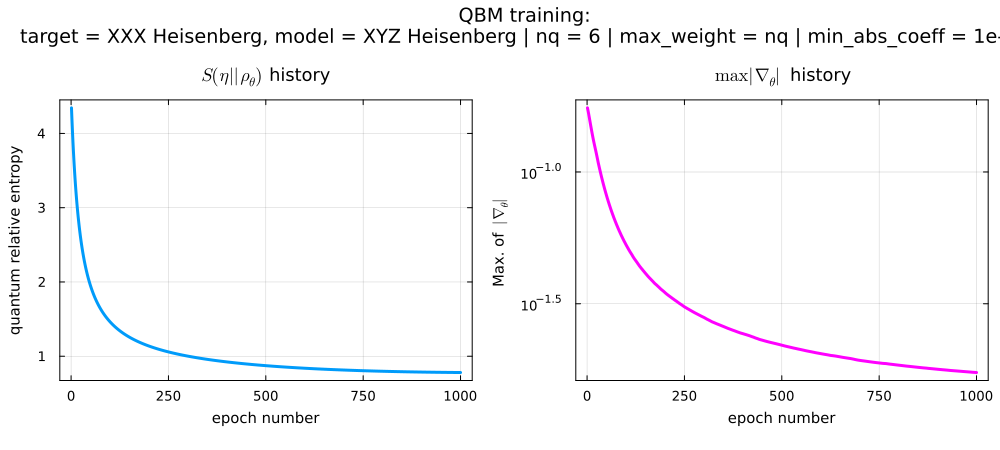

In [30]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    # yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training:\ntarget = XXX Heisenberg, model = XYZ Heisenberg | nq = 6 | max_weight = nq | min_abs_coeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)

In [31]:
params_target

HamiltonianParams(([0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]), ([4.0 4.0 … 4.0 4.0; 4.0 4.0 … 4.0 4.0; … ; 4.0 4.0 … 4.0 4.0; 4.0 4.0 … 4.0 4.0], [4.0 4.0 … 4.0 4.0; 4.0 4.0 … 4.0 4.0; … ; 4.0 4.0 … 4.0 4.0; 4.0 4.0 … 4.0 4.0], [4.0 4.0 … 4.0 4.0; 4.0 4.0 … 4.0 4.0; … ; 4.0 4.0 … 4.0 4.0; 4.0 4.0 … 4.0 4.0]))

In [35]:
params

33-element Vector{Float64}:
 -0.02440619693591063
 -0.024403386576692783
 -0.024402482949045484
 -0.02485599137485602
 -0.025271725728700404
 -0.026832057605342297
 -0.024961027556458015
 -0.025535625433488054
 -0.025912249650305065
 -0.024877535116044396
  ⋮
  1.5377695011304313
  1.5388914757194214
  1.5428208836943536
  1.3793415998107212
  1.3795898284160621
  1.3801046242040156
  1.1351707927279808
  1.1362727907042571
  1.1403288358085721

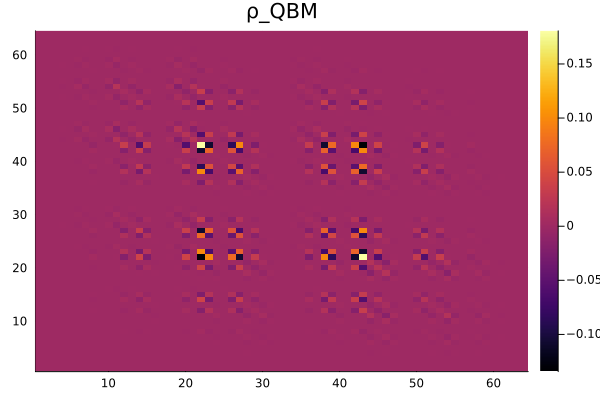

In [37]:
beta = 1.
qbm_tfim_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta
qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)

circuit, theta = paulistringtocircuit(qbm_tfim_paulis)

num_layers = 100
max_weight = n
min_abs_coeff = 1e-10
qbm = makethermalstate(n, circuit, theta, num_layers;
                                  max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
qbm_matrix = paulistringtomatrix(qbm)

heatmap(reverse(real(qbm_matrix); dims=1), title="ρ_QBM")

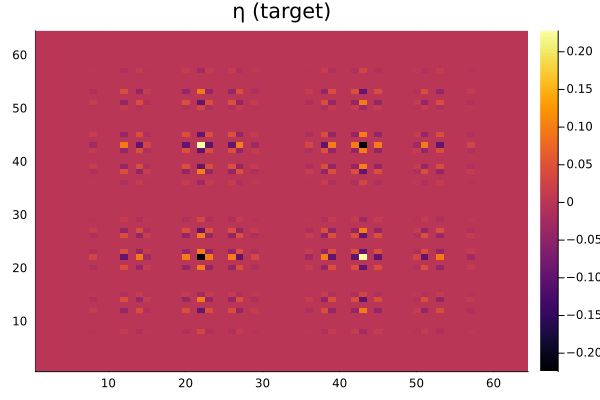

In [38]:
heatmap(reverse(real(target_eta_beta2_matrix); dims=1), title="η (target)")